In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.transforms import ScaledTranslation
from matplotlib import patheffects as pe
import seaborn as sns

mpl.rcParams['savefig.transparent'] = True
mpl.rcParams['font.family'] = 'Arial'

SAVEFIGS = True
DISPLAY_DPI = 150
EXPORT_DPI = 600

np.random.seed(42)  # For reproducibility of jitter

In [2]:
grain_cols = ["G0", "G1", "G2"]
nr_cols    = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols    = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

color_grain = "darkkhaki"
color_nr    = "dimgray"     # 20% Casein
color_pr    = "dodgerblue"  # 5% Casein

# For Order 1 (Grain -> NR -> PR)
o1_colors = (color_grain, color_nr, color_pr)
# For Order 2 (Grain -> PR -> NR)
o2_colors = (color_grain, color_pr, color_nr)

o1_ls = "--"  # dashed
o2_ls = "-"   # solid

In [3]:
#maybe needed helper functions for line plots
def annotate_near_line(ax, xi, y, ysem=np.nan, text='', side='above', offset_pts=3, fs=10, use_sem=True):
    """
    Place `text` at x=xi, just above/below the line.
    - offset_pts is in *points* (try 3–6 for visible changes).
    - if use_sem=True, we sit on the mean±SEM edge; if False, we sit on the mean.
    """
    # anchor on mean or mean±SEM
    base = y
    if use_sem and np.isfinite(ysem):
        base = y + (ysem if side == 'above' else -ysem)

    # build a data+screen transform with vertical offset in points
    sign = +1 if side == 'above' else -1
    trans = ax.transData + ScaledTranslation(0, sign * (offset_pts / 72.0), ax.figure.dpi_scale_trans)

    t = ax.text(
        xi, base, text,
        transform=trans,
        ha='center',
        va=('bottom' if side == 'above' else 'top'),
        fontsize=fs,
        zorder=7,
        clip_on=False,
    )
    t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])
    
def mask_below_threshold(data, threshold=50):
    arr = np.array(data, dtype=float)
    return np.where(arr >= threshold, arr, np.nan)

In [4]:
# helper functions

def get_data(df, order, cols, sex=None):
    
    if sex is not None:
        return (df
                .query("Order == @order and Sex == @sex")
                .loc[:, cols]
                .to_numpy(dtype=float)
                )
    else:
        return (df
                .query("Order == @order")
                .loc[:, cols]
                .to_numpy(dtype=float)
                )

def mean_sem(a, axis=0):
    a = np.asarray(a, dtype=float)
    mean = np.nanmean(a, axis=axis)
    n = np.sum(~np.isnan(a), axis=axis)
    std = np.nanstd(a, axis=axis, ddof=1)
    sem = std / np.sqrt(np.maximum(n, 1))
    sem[n <= 1] = np.nan
    return mean, sem

def line_kwargs(color, linestyle):
    return dict(
        color=color, linestyle=linestyle, linewidth=1.5,
        marker='o', markersize=5,
        markerfacecolor=color, markeredgecolor='none', markeredgewidth=0.35,
        solid_capstyle='butt', dash_capstyle='butt', # zorder=3
    )

# ===
def x_idx(order, phase, day_int):
    # O1: G(0..2), NR(3..9), PR(10..16)
    # O2: G(0..2), PR(3..9), NR(10..16)
    if order == 1:
        base = 0 if phase=='G' else (3 if phase=='NR' else 10)
    else:
        base = 0 if phase=='G' else (3 if phase=='PR' else 10)
    return base + day_int

In [5]:
### Main line plot function

def make_line_plot(o1_mean, o1_sem, o2_mean, o2_sem, ax=None,
                   o1_colors=o1_colors, o2_colors=o2_colors,
                   o1_ls=o1_ls, o2_ls=o2_ls):
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.5, 2.2), dpi=DISPLAY_DPI,
                               gridspec_kw={'left': 0.15, 'right': 0.85, 'top': 0.95, 'bottom': 0.3})
    else:
        fig = ax.figure
        
    x_grain = np.arange(0, 3)   # 0..2
    x_mid   = np.arange(2, 10)  # 2..9
    x_last  = np.arange(9, 17)  # 9..16

    # Order 1 (G, NR, PR)
    ax.plot(x_grain, o1_mean[x_grain], **line_kwargs(o1_colors[0], o1_ls), zorder=3)
    ax.fill_between(x_grain, o1_mean[x_grain]-o1_sem[x_grain], o1_mean[x_grain]+o1_sem[x_grain],
                    color=o1_colors[0], alpha=0.18, linewidth=0, zorder=1)
    ax.plot(x_mid,   o1_mean[x_mid],   **line_kwargs(o1_colors[1], o1_ls), zorder=2)
    ax.fill_between(x_mid, o1_mean[x_mid]-o1_sem[x_mid], o1_mean[x_mid]+o1_sem[x_mid],
                    color=o1_colors[1], alpha=0.18, linewidth=0, zorder=1)
    ax.plot(x_last,  o1_mean[x_last],  **line_kwargs(o1_colors[2], o1_ls), zorder=1)
    ax.fill_between(x_last, o1_mean[x_last]-o1_sem[x_last], o1_mean[x_last]+o1_sem[x_last],
                    color=o1_colors[2], alpha=0.18, linewidth=0, zorder=1)

    # Order 2 (G, PR, NR)
    ax.plot(x_grain, o2_mean[x_grain], **line_kwargs(o2_colors[0], o2_ls), zorder=3)
    ax.fill_between(x_grain, o2_mean[x_grain]-o2_sem[x_grain], o2_mean[x_grain]+o2_sem[x_grain],
                    color=o2_colors[0], alpha=0.18, linewidth=0, zorder=1)
    ax.plot(x_mid,   o2_mean[x_mid],   **line_kwargs(o2_colors[1], o2_ls), zorder=2)
    ax.fill_between(x_mid, o2_mean[x_mid]-o2_sem[x_mid], o2_mean[x_mid]+o2_sem[x_mid],
                    color=o2_colors[1], alpha=0.18, linewidth=0, zorder=1)
    ax.plot(x_last,  o2_mean[x_last],  **line_kwargs(o2_colors[2], o2_ls), zorder=1)
    ax.fill_between(x_last, o2_mean[x_last]-o2_sem[x_last], o2_mean[x_last]+o2_sem[x_last],
                    color=o2_colors[2], alpha=0.18, linewidth=0, zorder=1)

    ax.axvline(2, linestyle="-", color="indigo", alpha=0.2, linewidth=1)
    ax.axvline(9, linestyle="-", color="indigo", alpha=0.2, linewidth=1)
    
    ax.set_xticks(range(17))
    ax.set_xticklabels([str(i-2) for i in range(17)], fontsize=8)

    ax.set_xlabel("Day")
    ax.tick_params(axis='y', labelsize=8) 
    ax.tick_params(axis='x', labelsize=8) 

    sns.despine(ax=ax, offset=5)
    
    return fig, ax

In [6]:

_CONTRAST_TERM_RE = re.compile(r'([A-Z]+)(\d+)\s+Order(\d)(?:\s+Sex([A-Za-z]+))?$')


def load_spec_table(path):
    path = Path(path)
    if not path.exists():
        return pd.DataFrame(columns=["_contrast_str", "_p"])

    df = pd.read_csv(path)
    if df.empty:
        return pd.DataFrame(columns=["_contrast_str", "_p"])

    contrast_col = next((c for c in df.columns if "contrast" in c.lower()), df.columns[0])
    p_col = next((c for c in df.columns if "p.value" in c.lower() or ("p" in c.lower() and "value" in c.lower())), df.columns[-1])
    return df.assign(
        _contrast_str=df[contrast_col].astype(str),
        _p=pd.to_numeric(df[p_col], errors="coerce"),
    )


def stars_for_p(p):
    if pd.isna(p):
        return ""
    p = float(p)
    if p <= 0.001:
        return "***"
    if p <= 0.01:
        return "**"
    if p <= 0.05:
        return "*"
    return ""


def diamond_for_p(p):
    base = stars_for_p(p)
    return "D" * len(base) if base else ""


def daggers_for_p(p):
    base = stars_for_p(p)
    return "†" * len(base) if base else ""


def parse_contrast(label):
    parts = re.split(r"\s+-\s+", str(label).strip(), maxsplit=1)
    if len(parts) != 2:
        raise ValueError(f"Could not parse contrast label: {label!r}")

    parsed = []
    for part in parts:
        match = _CONTRAST_TERM_RE.search(part.strip())
        if match is None:
            raise ValueError(f"Could not parse contrast term: {part!r}")
        phase, day_int, order, _sex = match.groups()
        parsed.append((phase, int(day_int), int(order)))
    return tuple(parsed)


def _update_symbol_map(symbol_map, xi, symbol):
    current = symbol_map.get(xi, "")
    if len(symbol) >= len(current):
        symbol_map[xi] = symbol


def _target_x_from_contrast(label, *, target_order, target_phase=None):
    parsed = parse_contrast(label)
    candidates = []
    for phase, day_int, order in parsed:
        if order != target_order:
            continue
        if target_phase is not None and phase != target_phase:
            continue
        candidates.append((phase, day_int, order))

    if not candidates:
        return None

    # Prefer non-baseline days for baseline-vs-all contrasts (PR0-vs-PRk, NR0-vs-PRk, etc.).
    nonzero = [c for c in candidates if c[1] != 0]
    if nonzero:
        if target_phase is not None:
            for phase, day_int, order in nonzero:
                if phase == target_phase:
                    return x_idx(order, phase, day_int)
        phase, day_int, order = nonzero[0]
        return x_idx(order, phase, day_int)

    # Edge case: both terms are day 0 (e.g., PR0 vs NR0). In baseline-vs-all files,
    # the second term is the compared condition/day to annotate.
    if len(candidates) >= 2:
        phase, day_int, order = candidates[1]
        return x_idx(order, phase, day_int)

    phase, day_int, order = candidates[0]
    return x_idx(order, phase, day_int)


def load_nonsex_sig_positions(spec_dir):
    spec_dir = Path(spec_dir)
    sig_positions = {"stars": {}, "diamonds": {}, "dag_pr": {}, "dag_nr": {}}

    df_star = load_spec_table(spec_dir / "SPEC_O2_PR0_vs_all_Order2_days.csv")
    for _, row in df_star.iterrows():
        symbol = stars_for_p(row["_p"])
        if not symbol:
            continue
        xi = _target_x_from_contrast(row["_contrast_str"], target_order=2)
        if xi is not None:
            _update_symbol_map(sig_positions["stars"], xi, symbol)

    df_diamond = load_spec_table(spec_dir / "SPEC_O1_NR0_vs_all_Order1_days.csv")
    for _, row in df_diamond.iterrows():
        symbol = diamond_for_p(row["_p"])
        if not symbol:
            continue
        xi = _target_x_from_contrast(row["_contrast_str"], target_order=1)
        if xi is not None:
            _update_symbol_map(sig_positions["diamonds"], xi, symbol)

    for filename, phase_name, bucket_name in (
        ("SPEC_O2_PRk_vs_O1_NRk_matched_days.csv", "PR", "dag_pr"),
        ("SPEC_O2_NRk_vs_O1_PRk_matched_days.csv", "NR", "dag_nr"),
    ):
        df_dagger = load_spec_table(spec_dir / filename)
        for _, row in df_dagger.iterrows():
            symbol = daggers_for_p(row["_p"])
            if not symbol:
                continue
            xi = _target_x_from_contrast(row["_contrast_str"], target_order=2, target_phase=phase_name)
            if xi is not None:
                _update_symbol_map(sig_positions[bucket_name], xi, symbol)

    return sig_positions


def load_sex_sig_positions(spec_dir, sex_label):
    spec_dir = Path(spec_dir)
    sig_positions = {"stars": {}, "diamonds": {}, "dag_pr": {}, "dag_nr": {}}

    df_star = load_spec_table(spec_dir / f"SPEC_O2_PR0_vs_all_Order2_days_Sex{sex_label}.csv")
    for _, row in df_star.iterrows():
        symbol = stars_for_p(row["_p"])
        if not symbol:
            continue
        xi = _target_x_from_contrast(row["_contrast_str"], target_order=2)
        if xi is not None:
            _update_symbol_map(sig_positions["stars"], xi, symbol)

    df_diamond = load_spec_table(spec_dir / f"SPEC_O1_NR0_vs_all_Order1_days_Sex{sex_label}.csv")
    for _, row in df_diamond.iterrows():
        symbol = diamond_for_p(row["_p"])
        if not symbol:
            continue
        xi = _target_x_from_contrast(row["_contrast_str"], target_order=1)
        if xi is not None:
            _update_symbol_map(sig_positions["diamonds"], xi, symbol)

    for filename, phase_name, bucket_name in (
        (f"SPEC_O2_PRk_vs_O1_NRk_matched_days_Sex{sex_label}.csv", "PR", "dag_pr"),
        (f"SPEC_O2_NRk_vs_O1_PRk_matched_days_Sex{sex_label}.csv", "NR", "dag_nr"),
    ):
        df_dagger = load_spec_table(spec_dir / filename)
        for _, row in df_dagger.iterrows():
            symbol = daggers_for_p(row["_p"])
            if not symbol:
                continue
            xi = _target_x_from_contrast(row["_contrast_str"], target_order=2, target_phase=phase_name)
            if xi is not None:
                _update_symbol_map(sig_positions[bucket_name], xi, symbol)

    return sig_positions


def _normalize_significance_style(show_significance_rows=True, significance_style="rows"):
    if not show_significance_rows:
        return "none"
    style = "rows" if significance_style is None else str(significance_style).strip().lower()
    aliases = {
        "row": "rows",
        "rows": "rows",
        "band": "rows",
        "bands": "rows",
        "strip": "rows",
        "strips": "rows",
        "symbol": "symbols",
        "symbols": "symbols",
        "none": "none",
        "off": "none",
        "false": "none",
    }
    if style not in aliases:
        raise ValueError("significance_style must be one of: rows, symbols, none")
    return aliases[style]


def _symbol_to_alpha(symbol):
    if not symbol:
        return 0.0
    # Stronger visual separation among *, **, *** levels.
    return {1: 0.15, 2: 0.40, 3: 0.88}.get(len(str(symbol).strip()), 0.24)


def _build_stagger_offsets(xs, base_offset_pts=-6, step_pts=4):
    return {xi: base_offset_pts - step_pts * (idx % 2) for idx, xi in enumerate(sorted(xs))}


def _merge_strongest_by_x(*symbol_maps):
    merged = {}
    for symbol_map in symbol_maps:
        for xi, symbol in symbol_map.items():
            _update_symbol_map(merged, xi, symbol)
    return merged


def add_annotation_headroom(ax, o1_mean, o1_sem, o2_mean, o2_sem, top_frac=0.12, bottom_frac=0.16):
    lower, upper = ax.get_ylim()
    series_min = np.nanmin([
        np.nanmin(o1_mean - np.nan_to_num(o1_sem, nan=0.0)),
        np.nanmin(o2_mean - np.nan_to_num(o2_sem, nan=0.0)),
        lower,
    ])
    series_max = np.nanmax([
        np.nanmax(o1_mean + np.nan_to_num(o1_sem, nan=0.0)),
        np.nanmax(o2_mean + np.nan_to_num(o2_sem, nan=0.0)),
        upper,
    ])
    y_range = max(series_max - series_min, 1e-6)
    ax.set_ylim(series_min - y_range * bottom_frac, series_max + y_range * top_frac)
    return y_range


def _draw_significance_row(
    ax,
    symbol_map,
    row_index,
    *,
    color="#e6862a",
    label="",
    height=0.042,
    label_x=None,
):
    if not symbol_map:
        return

    # Slightly larger vertical spacing between rows and thicker row bands.
    y0 = 0.0 + row_index * 0.058
    y1 = y0 + height

    for xi, symbol in sorted(symbol_map.items()):
        alpha = _symbol_to_alpha(symbol)
        if alpha <= 0:
            continue
        ax.axvspan(
            xi - 0.32,
            xi + 0.32,
            ymin=y0,
            ymax=y1,
            facecolor=color,
            edgecolor="none",
            alpha=alpha,
            zorder=6,
            clip_on=False,
        )

    if label:
        # Use a shared label anchor for all rows so labels align with each other.
        if label_x is None:
            label_x = max(symbol_map.keys()) + 0.52
        trans = ax.get_xaxis_transform()  # x in data units, y in axes-fraction units
        ax.text(
            label_x,
            (y0 + y1) / 2.0,
            label,
            transform=trans,
            ha="left",
            va="center",
            fontsize=6,
            fontfamily="Arial",
            color=color,
            zorder=7,
            clip_on=False,
        )


def apply_significance_overlay(
    ax,
    o1_mean,
    o1_sem,
    o2_mean,
    o2_sem,
    *,
    spec_dir,
    sex_label=None,
    show_significance_rows=True,
    significance_style="rows",
    use_sem_anchor=True,
    symbol_fontsize=9,
    star_side="above",
    diamond_side="below",
    star_offset_pts=-6,
    diamond_offset_pts=-6,
):
    style = _normalize_significance_style(
        show_significance_rows=show_significance_rows,
        significance_style=significance_style,
    )
    if style == "none":
        return None

    sig_positions = load_nonsex_sig_positions(spec_dir) if sex_label is None else load_sex_sig_positions(spec_dir, sex_label)

    def y_at(order, xi):
        return (o1_mean[xi], o1_sem[xi]) if order == 1 else (o2_mean[xi], o2_sem[xi])

    if style == "symbols":
        y_range = add_annotation_headroom(ax, o1_mean, o1_sem, o2_mean, o2_sem)
        star_offsets = _build_stagger_offsets(sig_positions["stars"], base_offset_pts=star_offset_pts, step_pts=4)
        diamond_offsets = _build_stagger_offsets(sig_positions["diamonds"], base_offset_pts=diamond_offset_pts, step_pts=4)

        for xi, symbol in sig_positions["stars"].items():
            y_val, y_sem = y_at(2, xi)
            if np.isfinite(y_val):
                annotate_near_line(ax, xi, y_val, y_sem, symbol, side=star_side, offset_pts=star_offsets[xi], fs=symbol_fontsize, use_sem=use_sem_anchor)

        for xi, symbol in sig_positions["diamonds"].items():
            y_val, y_sem = y_at(1, xi)
            if np.isfinite(y_val):
                annotate_near_line(ax, xi, y_val, y_sem, symbol, side=diamond_side, offset_pts=diamond_offsets[xi], fs=symbol_fontsize, use_sem=use_sem_anchor)

        for bucket_name in ("dag_pr", "dag_nr"):
            for xi, symbol in sig_positions[bucket_name].items():
                y1, _ = y_at(1, xi)
                y2, _ = y_at(2, xi)
                if np.isfinite(y1) and np.isfinite(y2):
                    artist = ax.text(
                        xi,
                        (min(y1, y2) + max(y1, y2)) / 2.0,
                        symbol,
                        ha="center",
                        va="center",
                        fontsize=max(symbol_fontsize - 1, 7),
                        color="black",
                        zorder=7,
                    )
                    artist.set_path_effects([pe.withStroke(linewidth=1.2, foreground="white")])

        return y_range

    add_annotation_headroom(ax, o1_mean, o1_sem, o2_mean, o2_sem, bottom_frac=0.28)
    daggers = _merge_strongest_by_x(sig_positions["dag_pr"], sig_positions["dag_nr"])

    row_maps = [sig_positions["stars"], sig_positions["diamonds"], daggers]
    nonempty_maps = [m for m in row_maps if m]
    shared_label_x = max(max(m.keys()) for m in nonempty_maps) + 0.52 if nonempty_maps else None
    row_color = "#e6862a"

    # Top-to-bottom row labels as requested.
    _draw_significance_row(
        ax,
        sig_positions["stars"],
        row_index=2,
        color=row_color,
        label="vs. Day 1 (Order 2)",
        label_x=shared_label_x,
    )
    _draw_significance_row(
        ax,
        sig_positions["diamonds"],
        row_index=1,
        color=row_color,
        label="vs. Day 1 (Order 1)",
        label_x=shared_label_x,
    )
    _draw_significance_row(
        ax,
        daggers,
        row_index=0,
        color=row_color,
        label="Order 1 vs. Order 2",
        label_x=shared_label_x,
    )

    return sig_positions

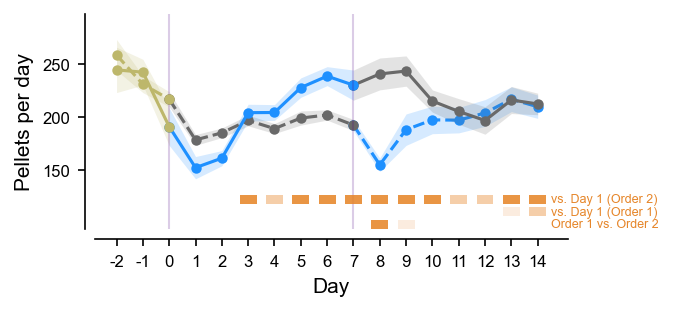

In [17]:
### Plot Fig 2

SAVEFIGS = True

# Prepare data
file_path = '../results/PELLET_INTAKE/pellets_trend.csv'
spec_dir = '../results/PELLET_INTAKE/RE_DO'
df_pellets_per_day = pd.read_csv(file_path)

o1_mean, o1_sem = mean_sem(get_data(df_pellets_per_day, 1, grain_cols + nr_cols + pr_cols), axis=0)
o2_mean, o2_sem = mean_sem(get_data(df_pellets_per_day, 2, grain_cols + pr_cols + nr_cols), axis=0)

# Make plot
fig, ax = make_line_plot(o1_mean, o1_sem, o2_mean, o2_sem)

# Adjust plot
ax.set_ylabel("Pellets per day", fontsize=10)
ax.set_yticks([150, 200, 250])
apply_significance_overlay(
    ax,
    o1_mean,
    o1_sem,
    o2_mean,
    o2_sem,
    spec_dir=spec_dir,
    significance_style="rows",
)

if SAVEFIGS:
    fig.savefig("../plots/Fig2B.pdf", dpi=EXPORT_DPI)

### Bodyweight

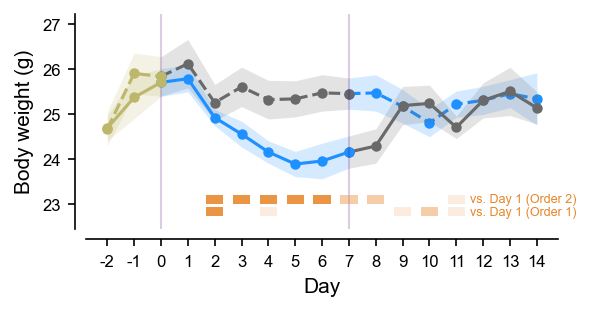

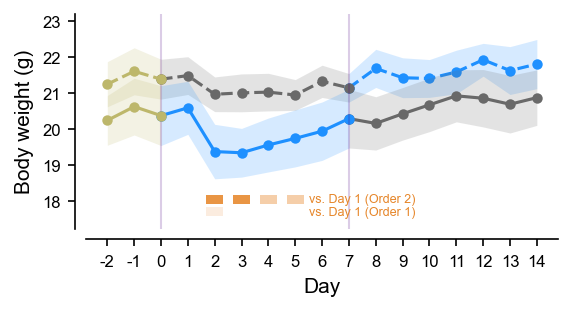

In [18]:
# Prepare data
file_path = '../results/Bodyweight/BODYWEIGHT.csv'
spec_dir = '../results/Bodyweight/RE_DO_BODYWEIGHT'
df = pd.read_csv(file_path)

# male data only
o1_mean, o1_sem = mean_sem(get_data(df, 1, grain_cols + nr_cols + pr_cols, sex="M"), axis=0)
o2_mean, o2_sem = mean_sem(get_data(df, 2, grain_cols + pr_cols + nr_cols, sex="M"), axis=0)

# Make figure
fig, ax = make_line_plot(o1_mean, o1_sem, o2_mean, o2_sem)

# Adjust plot
ax.set_ylabel("Body weight (g)", fontsize=10)
apply_significance_overlay(
    ax,
    o1_mean,
    o1_sem,
    o2_mean,
    o2_sem,
    spec_dir=spec_dir,
    sex_label="M",
    significance_style="rows",
)

if SAVEFIGS:
    fig.savefig("../plots/Fig3B.pdf", dpi=EXPORT_DPI)

# female data only
o1_mean, o1_sem = mean_sem(get_data(df, 1, grain_cols + nr_cols + pr_cols, sex="F"), axis=0)
o2_mean, o2_sem = mean_sem(get_data(df, 2, grain_cols + pr_cols + nr_cols, sex="F"), axis=0)

# Make figure
fig, ax = make_line_plot(o1_mean, o1_sem, o2_mean, o2_sem)

# Adjust plot
ax.set_ylabel("Body weight (g)", fontsize=10)
apply_significance_overlay(
    ax,
    o1_mean,
    o1_sem,
    o2_mean,
    o2_sem,
    spec_dir=spec_dir,
    sex_label="F",
    significance_style="rows",
)

if SAVEFIGS:
    fig.savefig("../plots/Fig3D.pdf", dpi=EXPORT_DPI)

### Number of meals

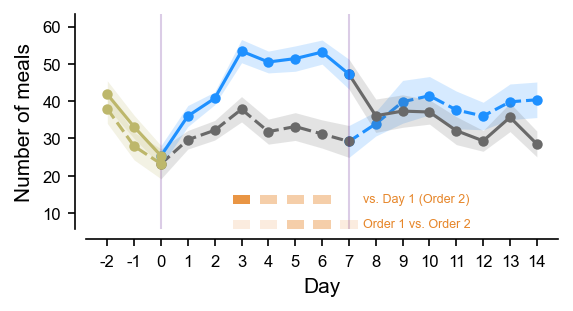

In [19]:
# Prepare data
trend_path = '../results/MEAL/meals_per_day_trend.csv'
spec_dir = '../results/MEAL/RE_DO_MEAL_NUMBER'
df_number_of_meals = pd.read_csv(trend_path)

o1_mean, o1_sem = mean_sem(get_data(df_number_of_meals, 1, grain_cols + nr_cols + pr_cols), axis=0)
o2_mean, o2_sem = mean_sem(get_data(df_number_of_meals, 2, grain_cols + pr_cols + nr_cols), axis=0)

# Make figure
fig, ax = make_line_plot(o1_mean, o1_sem, o2_mean, o2_sem)

# Adjust plot
ax.set_ylabel("Number of meals", fontsize=10)
apply_significance_overlay(
    ax,
    o1_mean,
    o1_sem,
    o2_mean,
    o2_sem,
    spec_dir=spec_dir,
    significance_style="rows",
)

if SAVEFIGS:
    fig.savefig("../plots/Fig5B.pdf", dpi=EXPORT_DPI)

### Meal size

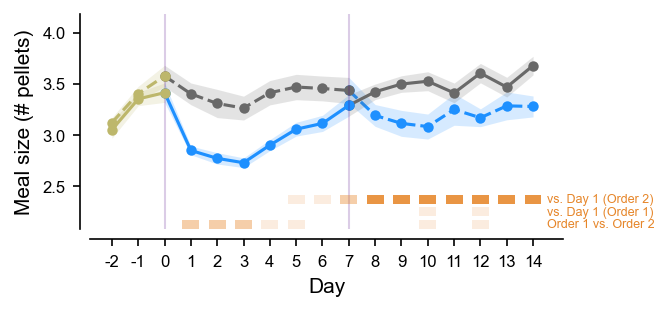

In [20]:
# Prepare data
trend_path = '../results/MEAL/meal_size_per_day/meal_size_realigned_FINAL.csv'
spec_dir = '../results/MEAL/meal_size_per_day/RE_DO_MEAL_SIZE'
df_mealsize = pd.read_csv(trend_path)

o1_mean, o1_sem = mean_sem(get_data(df_mealsize, 1, grain_cols + nr_cols + pr_cols), axis=0)
o2_mean, o2_sem = mean_sem(get_data(df_mealsize, 2, grain_cols + pr_cols + nr_cols), axis=0)

# Make figure
fig, ax = make_line_plot(o1_mean, o1_sem, o2_mean, o2_sem)

# Adjust plot
ax.set_ylabel("Meal size (# pellets)", fontsize=10)
ax.set_yticks([2.5, 3.0, 3.5, 4.0])
apply_significance_overlay(
    ax,
    o1_mean,
    o1_sem,
    o2_mean,
    o2_sem,
    spec_dir=spec_dir,
    significance_style="rows",
)

if SAVEFIGS:
    fig.savefig("../plots/Fig5D.pdf", dpi=EXPORT_DPI)

### Number of snacks

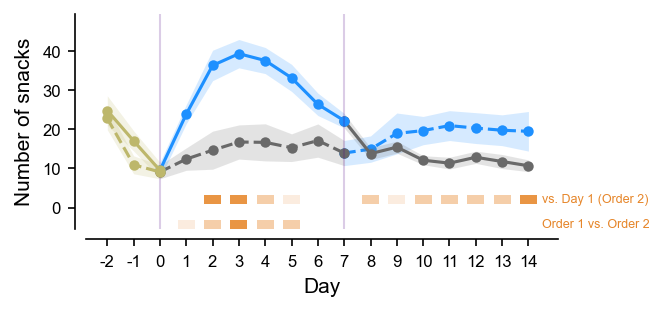

In [21]:
# Prepare data
trend_path = '../results/SNACK/snacks_per_day_trend.csv'
spec_dir = '../results/SNACK/RE_DO'
df_snacks = pd.read_csv(trend_path)

o1_mean, o1_sem = mean_sem(get_data(df_snacks, 1, grain_cols + nr_cols + pr_cols), axis=0)
o2_mean, o2_sem = mean_sem(get_data(df_snacks, 2, grain_cols + pr_cols + nr_cols), axis=0)

# Make figure
fig, ax = make_line_plot(o1_mean, o1_sem, o2_mean, o2_sem)

# Adjust plot
ax.set_ylabel("Number of snacks", fontsize=10)
apply_significance_overlay(
    ax,
    o1_mean,
    o1_sem,
    o2_mean,
    o2_sem,
    spec_dir=spec_dir,
    significance_style="rows",
)

if SAVEFIGS:
    fig.savefig("../plots/Fig6B.pdf", dpi=EXPORT_DPI)

### Number of feasts (male and female)

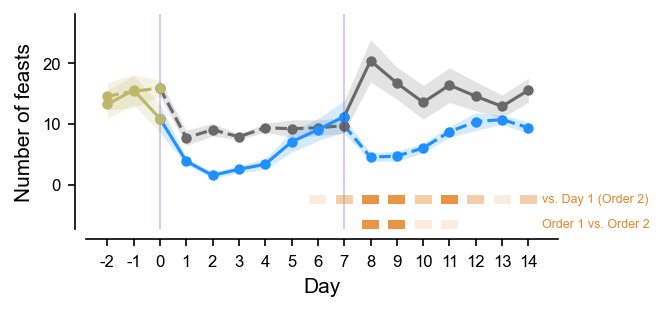

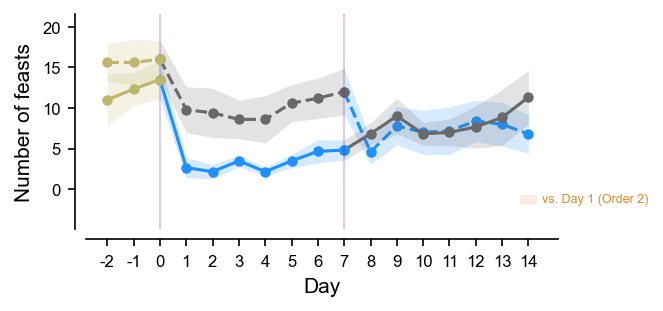

In [22]:
file_path = '../results/FEAST/mega_meals_per_day_trend.csv'
spec_dir = '../results/FEAST/FEAST_NUMBER_RE_DO'
df_number_of_feasts = pd.read_csv(file_path)

# male data only
o1_mean, o1_sem = mean_sem(get_data(df_number_of_feasts, 1, grain_cols + nr_cols + pr_cols, sex="M"), axis=0)
o2_mean, o2_sem = mean_sem(get_data(df_number_of_feasts, 2, grain_cols + pr_cols + nr_cols, sex="M"), axis=0)

# Make figure
fig, ax = make_line_plot(o1_mean, o1_sem, o2_mean, o2_sem)

# Adjust plot
ax.set_ylabel("Number of feasts", fontsize=10)
apply_significance_overlay(
    ax,
    o1_mean,
    o1_sem,
    o2_mean,
    o2_sem,
    spec_dir=spec_dir,
    sex_label="M",
    significance_style="rows",
)

if SAVEFIGS:
    fig.savefig("../plots/Fig7B.pdf", dpi=EXPORT_DPI)

# female data only
o1_mean, o1_sem = mean_sem(get_data(df_number_of_feasts, 1, grain_cols + nr_cols + pr_cols, sex="F"), axis=0)
o2_mean, o2_sem = mean_sem(get_data(df_number_of_feasts, 2, grain_cols + pr_cols + nr_cols, sex="F"), axis=0)

# Make figure
fig, ax = make_line_plot(o1_mean, o1_sem, o2_mean, o2_sem)

# Adjust plot
ax.set_ylabel("Number of feasts", fontsize=10)
apply_significance_overlay(
    ax,
    o1_mean,
    o1_sem,
    o2_mean,
    o2_sem,
    spec_dir=spec_dir,
    sex_label="F",
    significance_style="rows",
)

if SAVEFIGS:
    fig.savefig("../plots/Fig8B.pdf", dpi=EXPORT_DPI)

### Feast size

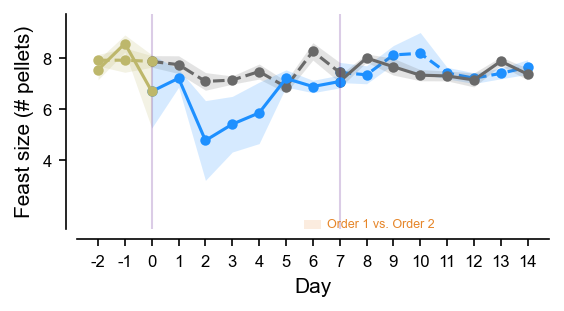

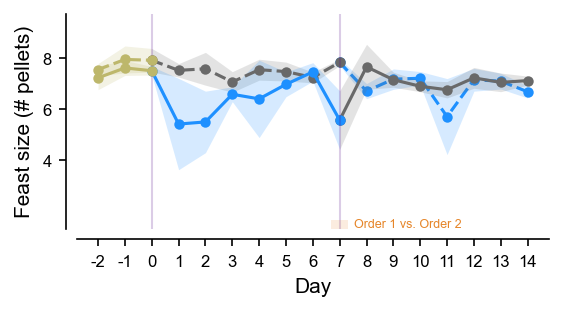

In [23]:
# Prepare data
file_path = '../results/FEAST/feast_size_per_day/mega_meal_size_realigned_FINAL.csv'
spec_dir = '../results/FEAST/feast_size_per_day/FEAST_SIZE_RE_DO'
df_feast_size = pd.read_csv(file_path)

# male data only
o1_mean, o1_sem = mean_sem(get_data(df_feast_size, 1, grain_cols + nr_cols + pr_cols, sex="M"), axis=0)
o2_mean, o2_sem = mean_sem(get_data(df_feast_size, 2, grain_cols + pr_cols + nr_cols, sex="M"), axis=0)

# Make figure
fig, ax = make_line_plot(o1_mean, o1_sem, o2_mean, o2_sem)

# Adjust plot
ax.set_ylabel("Feast size (# pellets)", fontsize=10)
ax.set_yticks([4, 6, 8])
ax.set_ylim(3, 9)
apply_significance_overlay(
    ax,
    o1_mean,
    o1_sem,
    o2_mean,
    o2_sem,
    spec_dir=spec_dir,
    sex_label="M",
    significance_style="rows",
)

if SAVEFIGS:
    fig.savefig("../plots/Fig7D.pdf", dpi=EXPORT_DPI)

# female data only
o1_mean, o1_sem = mean_sem(get_data(df_feast_size, 1, grain_cols + nr_cols + pr_cols, sex="F"), axis=0)
o2_mean, o2_sem = mean_sem(get_data(df_feast_size, 2, grain_cols + pr_cols + nr_cols, sex="F"), axis=0)

# Make figure
fig, ax = make_line_plot(o1_mean, o1_sem, o2_mean, o2_sem)

# Adjust plot
ax.set_ylabel("Feast size (# pellets)", fontsize=10)
ax.set_yticks([4, 6, 8])
ax.set_ylim(3, 9)
apply_significance_overlay(
    ax,
    o1_mean,
    o1_sem,
    o2_mean,
    o2_sem,
    spec_dir=spec_dir,
    sex_label="F",
    significance_style="rows",
)

if SAVEFIGS:
    fig.savefig("../plots/Fig8D.pdf", dpi=EXPORT_DPI)

### Interaction time

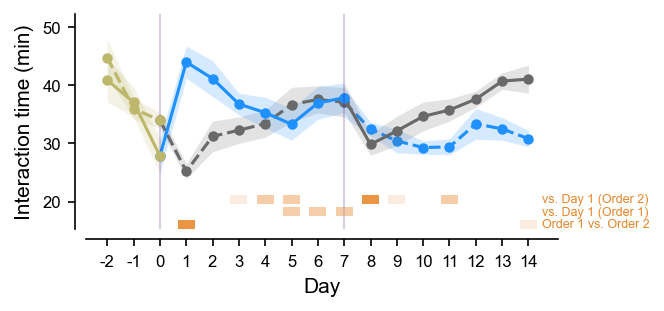

In [7]:
# Prepare data
trend_path = '../results/INTERACTION_TIME/INTER_TIME.csv'
spec_dir = '../results/INTERACTION_TIME/RE_DO'
df_interaction_time = pd.read_csv(trend_path)

o1_mean, o1_sem = mean_sem(get_data(df_interaction_time, 1, grain_cols + nr_cols + pr_cols), axis=0)
o2_mean, o2_sem = mean_sem(get_data(df_interaction_time, 2, grain_cols + pr_cols + nr_cols), axis=0)

# Make figure
fig, ax = make_line_plot(o1_mean, o1_sem, o2_mean, o2_sem)
ax.set_ylabel("Interaction time (min)", fontsize=10)
apply_significance_overlay(
    ax,
    o1_mean,
    o1_sem,
    o2_mean,
    o2_sem,
    spec_dir=spec_dir,
    significance_style="rows",
)

if SAVEFIGS:
    fig.savefig("../plots/Fig10.pdf", dpi=EXPORT_DPI)

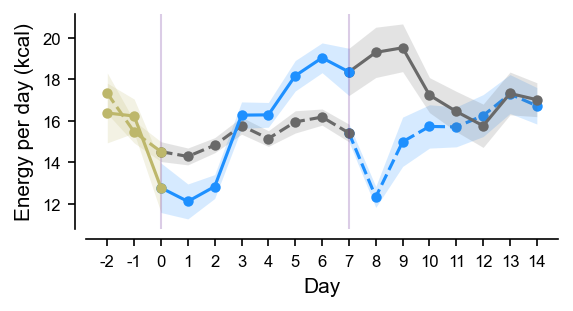

In [8]:
### Variant of Fig 2 to show energy (kcal) per day

grain_kcal = 3.35
nr_kcal = 4.01
pr_kcal = 3.99

# kcal per pellet (20 mg pellet mass)
grain_energy_kcal = 0.02 * grain_kcal
nr_energy_kcal = 0.02 * nr_kcal
pr_energy_kcal = 0.02 * pr_kcal

# Prepare data
file_path = '../results/PELLET_INTAKE/pellets_trend.csv'
spec_dir = '../results/PELLET_INTAKE/RE_DO'
df_pellets_per_day_scaled = pd.read_csv(file_path)

# Build order-specific scaling vectors using the diet energy density for each phase
o1_scale = np.array(
    [grain_energy_kcal] * 3 + [nr_energy_kcal] * 7 + [pr_energy_kcal] * 7,
    dtype=float,
 )
o2_scale = np.array(
    [grain_energy_kcal] * 3 + [pr_energy_kcal] * 7 + [nr_energy_kcal] * 7,
    dtype=float,
 )

# Extract order-specific arrays and apply scaling
o1_data = get_data(df_pellets_per_day_scaled, 1, grain_cols + nr_cols + pr_cols).astype(float) * o1_scale
o2_data = get_data(df_pellets_per_day_scaled, 2, grain_cols + pr_cols + nr_cols).astype(float) * o2_scale

# Compute means/SEMs
o1_mean, o1_sem = mean_sem(o1_data, axis=0)
o2_mean, o2_sem = mean_sem(o2_data, axis=0)

# Make plot
fig, ax = make_line_plot(o1_mean, o1_sem, o2_mean, o2_sem)

# Adjust plot
ax.set_ylabel('Energy per day (kcal)', fontsize=10)
# apply_significance_overlay(
#     ax,
#     o1_mean,
#     o1_sem,
#     o2_mean,
#     o2_sem,
#     spec_dir=spec_dir,
#     significance_style='rows',
# )

if SAVEFIGS:
    fig.savefig('../plots/FigS1_kcal_per_day.pdf', dpi=EXPORT_DPI)

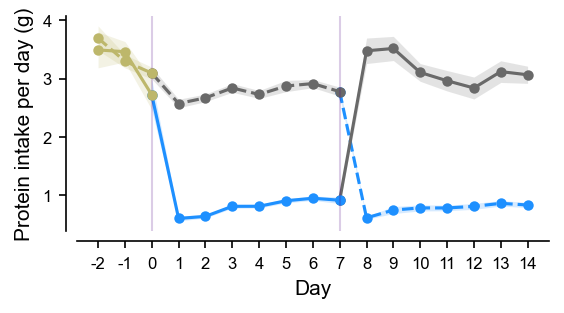

In [9]:
### Variant of Fig 2 to show protein intake 

grain_kcal = 3.35
nr_kcal = 4.01
pr_kcal = 3.99

grain_protein_g = 0.02 * grain_kcal * 0.213
nr_protein_g = 0.02 * nr_kcal * 0.18
pr_protein_g = 0.02 * pr_kcal * 0.05

# Prepare data
file_path = '../results/PELLET_INTAKE/pellets_trend.csv'
spec_dir = '../results/PELLET_INTAKE/RE_DO'
df_pellets_per_day_scaled_order = pd.read_csv(file_path)

# Scaling rules
first_3_scale = grain_protein_g
mid_7_o1_scale = nr_protein_g   # 0.8
last_7_o1_scale = pr_protein_g # 0.2
mid_7_o2_scale = pr_protein_g  # 0.2
last_7_o2_scale = nr_protein_g  # 0.8

# Build order-specific scaling vectors for aligned day positions (length 17)
o1_scale = np.array([first_3_scale] * 3 + [mid_7_o1_scale] * 7 + [last_7_o1_scale] * 7, dtype=float)
o2_scale = np.array([first_3_scale] * 3 + [mid_7_o2_scale] * 7 + [last_7_o2_scale] * 7, dtype=float)

# Extract order-specific arrays and apply scaling
o1_data = get_data(df_pellets_per_day_scaled_order, 1, grain_cols + nr_cols + pr_cols).astype(float) * o1_scale
o2_data = get_data(df_pellets_per_day_scaled_order, 2, grain_cols + pr_cols + nr_cols).astype(float) * o2_scale

# Compute means/SEMs
o1_mean, o1_sem = mean_sem(o1_data, axis=0)
o2_mean, o2_sem = mean_sem(o2_data, axis=0)

# Make plot
fig, ax = make_line_plot(o1_mean, o1_sem, o2_mean, o2_sem)

# Adjust plot
ax.set_ylabel('Protein intake per day (g)', fontsize=10)
# apply_significance_overlay(
#     ax,
#     o1_mean,
#     o1_sem,
#     o2_mean,
#     o2_sem,
#     spec_dir=spec_dir,
#     significance_style='rows',
# )

if SAVEFIGS:
    fig.savefig('../plots/FigS2_protein_intake.pdf', dpi=EXPORT_DPI)